**Purpose**
This cell imports all of the libraries and project modules the notebook relies on. It brings in SymPy for symbolic math and parsing user input into expressions, `pandas` for later data handling/plotting support, and the root‑finding routines implemented in the `method/` package (bisection, Newton, secant, simple iteration, and Aitken acceleration). It also imports the analysis helpers from `analysis/choice1.py` and `analysis/choice2.py`, which are used later to produce detailed comparison reports and plots.


In [1]:
from sympy import symbols, sympify
from sympy.core.sympify import SympifyError
import pandas as pd

from method.aitken import aitkenـmethod
from method.bisection import bisection_method
from method.newton import newton_method
from method.secant import secant_method
from method.simpleiteration import simpleـiteration

from analysis.choice1 import user_choice_one
from analysis.choice2 import user_choice_two

**Purpose**
This cell prompts the user for the symbol used in their equation (for example, `x`). It loops until a valid symbol is created via `sympy.symbols`. If parsing fails, it prints an error and retries. On success, the chosen symbol is stored in `x` for use in all subsequent symbolic expressions.


In [12]:
input_check = False
while input_check == False:
    try:
        x = symbols(input("Enter your equation's symbol: ").lower())
        input_check = True
    except:
        print("Invalid input. Please enter again")

**Purpose**
This cell asks the user for the function expression and parses it with `sympify`. It ensures the resulting expression only contains the previously selected symbol `x` (no extra variables). If parsing fails or unexpected variables are present, it reports the issue and re‑prompts until a valid expression is provided. The accepted expression is stored in `f`.


In [16]:
function_check = False
while function_check == False:
    try :
        user_input = input("Enter your equation: ")
        f = sympify(user_input.lower())

        if not f.free_symbols.issubset({x}):
            print(f"Function must only contain the variable '{x}'. Try again.")
            continue

        function_check = True
    except(SympifyError, ValueError):
        print("Invalid Function Input. Please Enter your function again")

**Purpose**
This cell defines and uses `ab_check()` to validate a numeric interval `[a, b]` for root finding. The helper function repeatedly prompts for `a` and `b`, converts them to SymPy values, and enforces that they are real numbers. After obtaining a valid pair, the cell additionally checks that the function changes sign on the interval (`f(a) * f(b) < 0`), which is required for the bisection and bracketing logic. If the sign condition is not met, it keeps asking for a new interval.


In [17]:
def ab_check():
    a_or_b_check = False
    while a_or_b_check == False:
        a_input = input("Enter a: ")
        b_input = input("Enter b: ")
        try:
            a = sympify(a_input)
            b = sympify(b_input)
            if not a.is_real or not b.is_real:
                raise ValueError("Inputs must be real numbers.")
            a_or_b_check = True
            return a , b
        except(SympifyError, ValueError):
            print("Invalid input. Please enter real numeric values for a and b.")

a , b  = ab_check()

while f.subs(x, a) * f.subs(x, b) >= 0:
    print("Invalid base, enter again: ")
    a , b = ab_check()

**Purpose**
This cell runs **Step 1** of the numerical methods. It calls each root‑finding routine in its “fixed‑iteration/early‑stop” mode (`step1=True`) and stores the iteration sequences:
- Bisection, Newton, and Secant directly.
- Additional Secant runs initialized from the most recent Bisection and Newton iterates.
- Simple Iteration, seeded from the latest Bisection estimate.
It then applies Aitken’s Δ² acceleration to each sequence to produce accelerated estimates. These results are saved for printing and later analysis.


In [18]:
print('==================== Step 1 ====================')

bisection_method_answers = bisection_method(a , b, True, f, x)
newton_method_answers = newton_method(a,b , f, True, x)
secant_method_answers_based_on_a_b = secant_method(a, b, True, f, x)
secant_method_answers_based_on_bisection_method_answers = secant_method(bisection_method_answers[-2], bisection_method_answers[-3], True, f, x)
secant_method_answers_based_on_newton_method_answers = secant_method(newton_method_answers[-2], newton_method_answers[-3], True, f, x)
simpleـiteration_answers = simpleـiteration(bisection_method_answers[-2], True, x, f, a, b)

aitkenـmethod_answers_based_on_bisection_method_answers = aitkenـmethod(bisection_method_answers[:-1])
aitkenـmethod_answers_based_on_newton_method_answers = aitkenـmethod(newton_method_answers[:-1])
aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b = aitkenـmethod(secant_method_answers_based_on_a_b[:-1])
aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers = aitkenـmethod(secant_method_answers_based_on_bisection_method_answers[:-1])
aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers = aitkenـmethod(secant_method_answers_based_on_newton_method_answers[:-1])
aitkenـmethod_answers_based_on_simpleـiteration_answers = aitkenـmethod(simpleـiteration_answers[:-1])

==================== Step 1 ====================
Best g(x): 1/sqrt(x + 1)


**Purpose**
This cell prints the full list of values produced by the bisection method in Step 1, including the stop reason string appended by the method implementation.


In [19]:
print('bisection method answers: ')
print(bisection_method_answers)

bisection method answers: 
[0.7500000000000000000, 0.8750000000000000000, 0.8125000000000000000, 0.7812500000000000000, 0.7656250000000000000, 0.7578125000000000000, 0.7539062500000000000, 0.7558593750000000000, 0.7548828125000000000, 0.7543945312500000000, 'Full Iteration of 10 steps']


**Purpose**
This cell prints the list of Newton method iterates from Step 1, including the stop reason appended at the end.


In [20]:
print('Newton Method answers:')
print(newton_method_answers)

Newton Method answers:
[0.7500000000000000000, 0.7549019607843137255, 0.7548776668452124842, 0.7548776662466927604, 'Stop Condition 2 occurred. | Xi+1 - Xi | < ε ']


**Purpose**
This cell prints the sequence from the Secant method initialized with the original interval endpoints `a` and `b` (Step 1 mode).


In [21]:
print('Secant Method answers based on a and b:')
print(secant_method_answers_based_on_a_b)

Secant Method answers based on a and b:
[0.6923076923076922906, 0.7411944869831546669, 0.7519692550742273334, 0.7542633025950661233, 0.7547480612754503410, 0.7548503326579299321, 0.7548719019530719457, 0.7548764506482268593, 0.7548774098968500992, 0.7548776121867318403, 'Full Iteration of 10 steps']


**Purpose**
This cell prints the Secant method sequence that was initialized using the last two bisection iterates (Step 1 mode).


In [22]:
print('Secant Method answers based on bisection method answers:')
print(secant_method_answers_based_on_bisection_method_answers)

Secant Method answers based on bisection method answers:
[0.7548776637244741602, 0.7548776662466795972, 0.7548776662466927600, 'Stop Condition 2 occurred. | Xi+1 - Xi | < ε ']


**Purpose**
This cell prints the Secant method sequence that was initialized using the last two Newton iterates (Step 1 mode).


In [23]:
print('Secant Method answers based on Newton Method answers:')
print(secant_method_answers_based_on_newton_method_answers)

Secant Method answers based on Newton Method answers:
[0.7548776662466927600, 0.7548776662466927600, 'Stop Condition 2 occurred. | Xi+1 - Xi | < ε ']


**Purpose**
This cell prints the selected Simple Iteration sequence from Step 1. The `simple_iteration` function evaluates multiple candidate `g(x)` forms and returns the “best” convergent sequence; this output is the chosen sequence.


In [24]:
print('Simple Iteration answers:')
print(simpleـiteration_answers)

Simple Iteration answers:
[0.7543945312500000000, 0.7549816003125273467, 0.7548553131158423122, 0.7548824740007536136, 0.7548766321977735753, 0.7548778886498821323, 0.7548776184122516960, 0.7548776765349175946, 0.7548776640339028693, 0.7548776667226192882, 0.7548776661443305516]


**Purpose**
This cell prints the Aitken‑accelerated sequence built from the Step 1 bisection iterates.


In [25]:
print('Aitken Method answers based on bisection method answers:')
print(aitkenـmethod_answers_based_on_bisection_method_answers)

Aitken Method answers based on bisection method answers:
[-0.2692307692307692308, 0.1200000000000000000, 0.06122448979591836734, 0.03092783505154639176, 0.01554404145077720206, 0.007792312661498707993, -0.003911303363518758098, 0.001951860841423948235]


**Purpose**
This cell prints the Aitken‑accelerated sequence built from the Step 1 Newton iterates.


In [26]:
print('Aitken Method answers based on Newton Method answers:')
print(aitkenـmethod_answers_based_on_newton_method_answers)

Aitken Method answers based on Newton Method answers:
[-0.009835753507213437541, 0.00004858709635993592761]


**Purpose**
This cell prints the Aitken‑accelerated sequence built from the Step 1 Secant‑(a,b) iterates.


In [27]:
print('Aitken Method answers based on Secant Method answers based on and b:')
print(aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b)

Aitken Method answers based on Secant Method answers based on and b:
[-0.1009518026588676500, -0.02170345541302527527, -0.004595067771119207213, -0.0009698286688093029414, -0.0002045566208672470977, -0.00004313920658950679454, -9.097417719082506867e-6, -1.918498465429500097e-6]


**Purpose**
This cell prints the Aitken‑accelerated sequence built from the Step 1 Secant‑(bisection) iterates.


In [28]:
print('Aitken Method answers based on Secant Method answers based on bisection method answers:')
print(aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers)

Aitken Method answers based on Secant Method answers based on bisection method answers:
[-5.044410882439672589e-9]


**Purpose**
This cell prints the Aitken‑accelerated sequence built from the Step 1 Secant‑(Newton) iterates.


In [29]:
print('Aitken Method answers based on Secant Method answers based on Newton Method answers:')
print(aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers)

Aitken Method answers based on Secant Method answers based on Newton Method answers:
Len of Sequence is lower than 3. Can not user Aitken method on this Sequence


**Purpose**
This cell prints the Aitken‑accelerated sequence built from the Step 1 Simple Iteration iterates.


In [30]:
print('Aitken Method answers based on Simple Iteration_answers:')
print(aitkenـmethod_answers_based_on_simpleـiteration_answers)

Aitken Method answers based on Simple Iteration_answers:
[-0.001174594702730160978, 0.0002525532662985104841, -0.00005432274708648643737, 0.00001168356075188786572, -2.512906308409077654e-6, 5.404751641305543131e-7, -1.162453362723041197e-7, 2.500202924351374069e-8]


**Purpose**
This cell runs **Step 2** of the numerical methods. In this mode (`step1=False`), each method uses a convergence criterion based on relative change rather than a fixed iteration count. It computes new sequences for bisection, Newton, secant (with multiple initializations), and simple iteration, and then applies Aitken acceleration to each Step 2 sequence.


In [34]:
print('==================== Step 2 ====================')

bisection_method_answers_step2 = bisection_method(a , b, False, f, x)
newton_method_answers_step2 = newton_method(a,b , f, False, x)
secant_method_answers_based_on_a_b_step2 = secant_method(a, b, False, f, x)
secant_method_answers_based_on_bisection_method_answers_step2 = secant_method(bisection_method_answers_step2[-1], bisection_method_answers_step2[-2], False, f, x)
secant_method_answers_based_on_newton_method_answers_step2 = secant_method(newton_method_answers_step2[-1], newton_method_answers_step2[-2], False, f, x)
simpleـiteration_answers_step2 = simpleـiteration(bisection_method_answers_step2[-1], False, x, f, a, b)

aitkenـmethod_answers_based_on_bisection_method_answers_step2 = aitkenـmethod(bisection_method_answers_step2)
aitkenـmethod_answers_based_on_newton_method_answers_step2 = aitkenـmethod(newton_method_answers_step2)
aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b_step2 = aitkenـmethod(secant_method_answers_based_on_a_b_step2)
aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers_step2 = aitkenـmethod(secant_method_answers_based_on_bisection_method_answers_step2)
aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers_step2 = aitkenـmethod(secant_method_answers_based_on_newton_method_answers_step2)
aitkenـmethod_answers_based_on_simpleـiteration_answers_step2 = aitkenـmethod(simpleـiteration_answers_step2)

==================== Step 2 ====================
Best g(x): 1/sqrt(x + 1)


**Purpose**
This cell prints the bisection method sequence computed in Step 2 (convergence‑based mode).


In [35]:
print('bisection method answers: ')
print(bisection_method_answers_step2)

bisection method answers: 
[0.7500000000000000000, 0.8750000000000000000, 0.8125000000000000000, 0.7812500000000000000, 0.7656250000000000000, 0.7578125000000000000, 0.7539062500000000000, 0.7558593750000000000, 0.7548828125000000000, 0.7543945312500000000, 0.7546386718750000000, 0.7547607421875000000, 0.7548217773437500000, 0.7548522949218750000, 0.7548675537109375000, 0.7548751831054687500, 0.7548789978027343750, 0.7548770904541015625, 0.7548780441284179688, 0.7548775672912597656]


**Purpose**
This cell prints the Newton method sequence computed in Step 2.


In [36]:
print('Newton Method answers:')
print(newton_method_answers_step2)

Newton Method answers:
[0.7500000000000000000, 0.7549019607843137255, 0.7548776668452124842, 0.7548776662466927604]


**Purpose**
This cell prints the Step 2 Secant sequence initialized with `a` and `b`.


In [37]:
print('Secant Method answers based on a and b:')
print(secant_method_answers_based_on_a_b_step2)

Secant Method answers based on a and b:
[0.6923076923076922906, 0.7411944869831546669, 0.7519692550742273334, 0.7542633025950661233, 0.7547480612754503410, 0.7548503326579299321, 0.7548719019530719457, 0.7548764506482268593, 0.7548774098968500992, 0.7548776121867318403]


**Purpose**
This cell prints the Step 2 Secant sequence initialized with the last two bisection iterates.


In [38]:
print('Secant Method answers based on bisection method answers:')
print(secant_method_answers_based_on_bisection_method_answers_step2)

Secant Method answers based on bisection method answers:
[0.7548776662466548398, 0.7548776662466927600]


**Purpose**
This cell prints the Step 2 Secant sequence initialized with the last two Newton iterates.


In [39]:
print('Secant Method answers based on Newton Method answers:')
print(secant_method_answers_based_on_newton_method_answers_step2)

Secant Method answers based on Newton Method answers:
[0.7548776662466927600, 0.7548776662466927600]


**Purpose**
This cell prints the Step 2 Simple Iteration sequence selected by the `simple_iteration` routine.


In [40]:
print('Simpl ـIteration_answers:')
print(simpleـiteration_answers_step2)

Simpl ـIteration_answers:
[0.7548775672912597656, 0.7548776875300137907]


**Purpose**
This cell prints the Aitken‑accelerated sequence from the Step 2 bisection iterates.


In [41]:
print('Aitken Method answers based on bisection method answers:')
print(aitkenـmethod_answers_based_on_bisection_method_answers_step2)

Aitken Method answers based on bisection method answers:
[-0.2692307692307692308, 0.1200000000000000000, 0.06122448979591836734, 0.03092783505154639176, 0.01554404145077720206, 0.007792312661498707993, -0.003911303363518758098, 0.001951860841423948235, 0.0009762465626010999613, -0.0004883602215752870827, -0.0002441603662974044025, -0.0001220752476248231251, -0.00006103639000626631238, -0.00003051788656094925290, -0.00001525886617109766452, -7.629413808448110360e-6, 3.814692446331543942e-6, -1.907349837636609403e-6]


**Purpose**
This cell prints the Aitken‑accelerated sequence from the Step 2 Newton iterates.


In [42]:
print('Aitken Method answers based on Newton Method answers:')
print(aitkenـmethod_answers_based_on_newton_method_answers_step2)

Aitken Method answers based on Newton Method answers:
[-0.009835753507213437541, 0.00004858709635993592761]


**Purpose**
This cell prints the Aitken‑accelerated sequence from the Step 2 Secant‑(a,b) iterates.


In [43]:
print('Aitken Method answers based on Secant Method answers based on and b:')
print(aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b_step2)

Aitken Method answers based on Secant Method answers based on and b:
[-0.1009518026588676500, -0.02170345541302527527, -0.004595067771119207213, -0.0009698286688093029414, -0.0002045566208672470977, -0.00004313920658950679454, -9.097417719082506867e-6, -1.918498465429500097e-6]


**Purpose**
This cell prints the Aitken‑accelerated sequence from the Step 2 Secant‑(bisection) iterates.


In [44]:
print('Aitken Method answers based on Secant Method answers based on bisection method answers:')
print(aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers_step2)

Aitken Method answers based on Secant Method answers based on bisection method answers:
Len of Sequence is lower than 3. Can not user Aitken method on this Sequence


**Purpose**
This cell prints the Aitken‑accelerated sequence from the Step 2 Secant‑(Newton) iterates.


In [45]:
print('Aitken Method answers based on Secant Method answers based on Newton Method answers:')
print(aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers_step2)

Aitken Method answers based on Secant Method answers based on Newton Method answers:
Len of Sequence is lower than 3. Can not user Aitken method on this Sequence


**Purpose**
This cell prints the Aitken‑accelerated sequence from the Step 2 Simple Iteration iterates.


In [46]:
print('Aitken Method answers based on Simple Iteration_answers:')
print(aitkenـmethod_answers_based_on_simpleـiteration_answers_step2) 

Aitken Method answers based on Simple Iteration_answers:
Len of Sequence is lower than 3. Can not user Aitken method on this Sequence


**Purpose**
This cell asks the user whether they want to proceed to the analysis section. The answer is stored in `user_choice` and used to gate the analysis logic in the next cell.


In [47]:
user_choice = input("Do you want to continue to analyze part (y/n) ? ")

**Purpose**
This cell implements the interactive analysis workflow. If the user chose to continue, it prints the entered function details, optionally collects a known root (so error comparisons can be computed), and then asks whether to analyze Part 1 or Part 2. It calls `user_choice_one` or `user_choice_two` from the `analysis/` module with all method outputs and the optional root, and offers the user a chance to run the other analysis part before exiting. If the user opted out at the start, it simply thanks them and ends.


Welcome to the analyze part. In this part you can analyze the function you entered.
first here is the geneal details of the function you entered:
Function: x**3 + x**2 - 1
Symbol: x
Interval: [0.500000000000000, 1]


No problem, Please countinue.
Welcome to the analyze part 1. In this part all step 1 details of the function you entered will be shown.
now here is the details of the function you entered in step 1:


Final answers of methods:
Bisection Method finall answer: 0.7543945312500000000
Newton Method finall answer: 0.7548776662466927604
Secant Method based on a and b final answer: 0.7548776121867318403
Secant Method based on bisection method finall answer: 0.7548776662466927600
Secant Method based on Newton Method final answer: 0.7548776662466927600
Simple Iteration final answer: 0.7548776667226192882


/home/norbert/Projects/sp - 1/analysis/choice1.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="Method Names", y="Finall Answers", join=True, capsize=0.1)


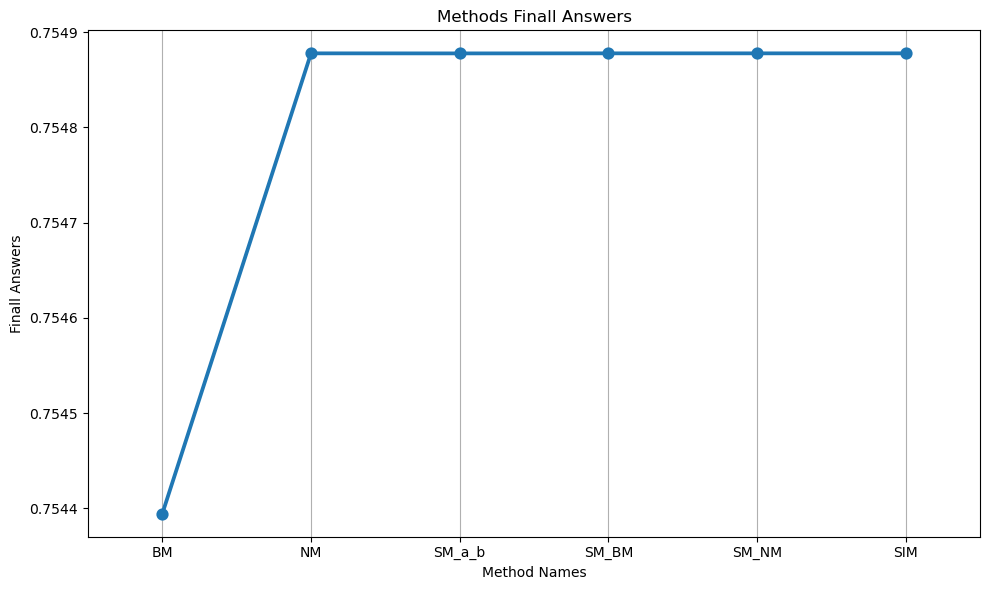

Difference between methods:
Difference between bisection method and Newton Method : 0.0004831349966927604147
Difference between bisection method and Secant Method based on a and b : 0.0004830809367318403188
Difference between bisection method and Secant Method based on bisection method answers : 0.0004831349966927599810
Difference between bisection method and Secant Method based on Newton Method answers : 0.0004831349966927600488
Difference between bisection method and Simple Iteration : 0.0004831354726192882437
--------------------------------
Difference between Newton Method and Secant Method based on a and b : 5.405996092009595407E-8
Difference between Newton Method and Secant Method based on bisection method answers : 4.336808689942017736E-19
Difference between Newton Method and Secant Method based on Newton Method answers : 3.659182332138577465E-19
Difference between Newton Method and Simple Iteration : 4.759265278289582721E-10
--------------------------------
Difference between S

/home/norbert/Projects/sp - 1/analysis/choice1.py:72: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="Method Comparison", y="Difference", join=True, capsize=0.1)


<Figure size 1000x600 with 0 Axes>

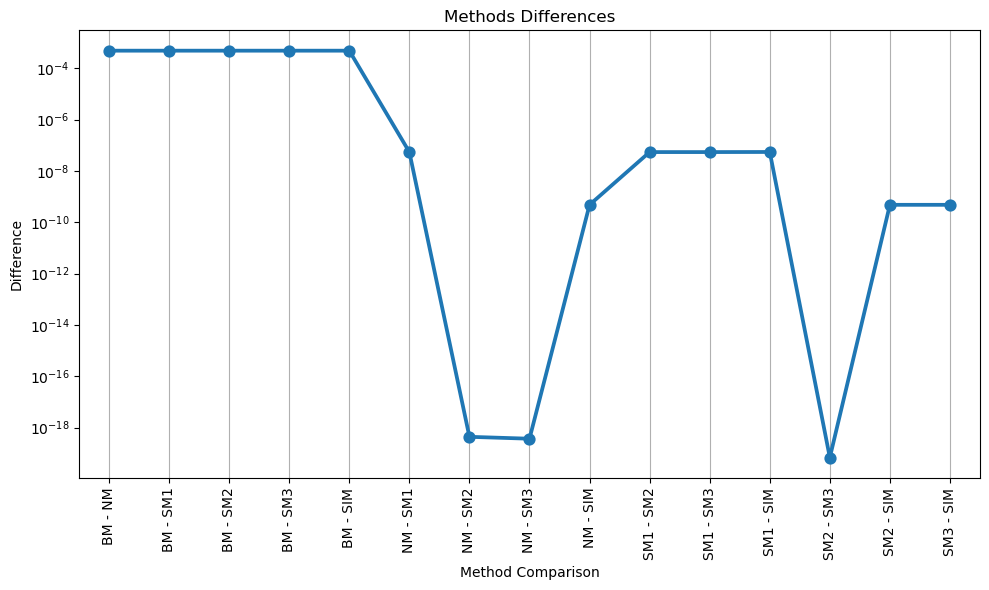

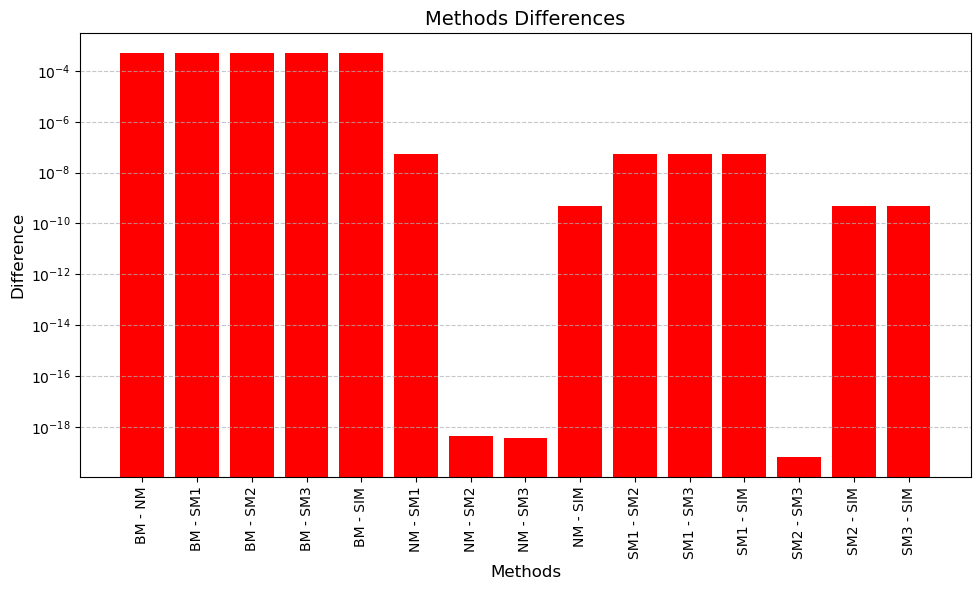

Length of methods:
bisection_method_answers: 11
Newton Method answers: 5
Secant Method answers based on a and b: 11
Secant Method answers based on bisection method answers: 4
Secant Method answers based on Newton Method answers: 3
Simple Iteration answers: 11
Fastest Method: ('secant_method_answers_based_on_newton_method_answers', 3)


/home/norbert/Projects/sp - 1/analysis/choice1.py:162: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="method_names", y="lengths", join=True, capsize=0.1)


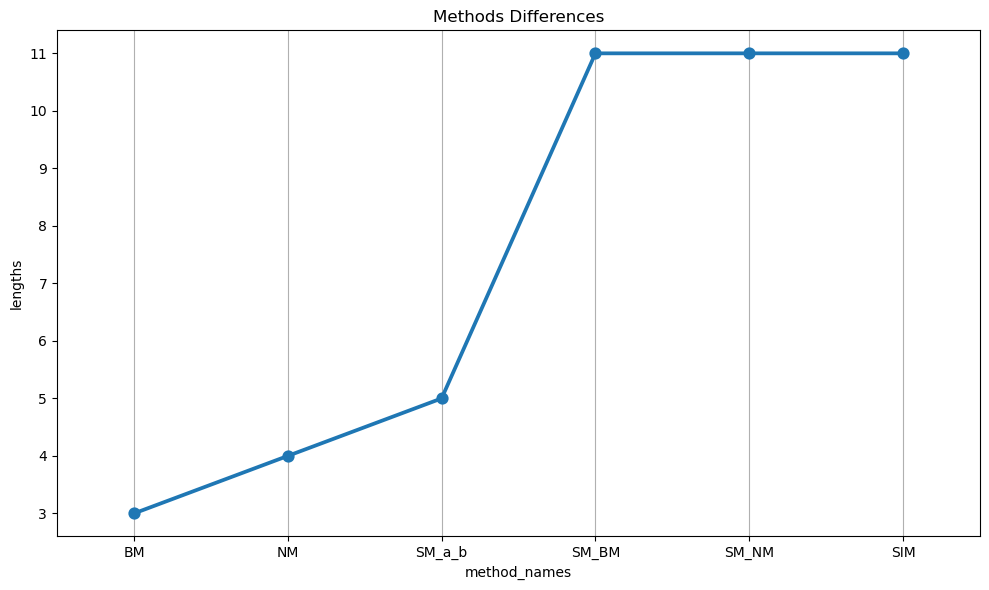

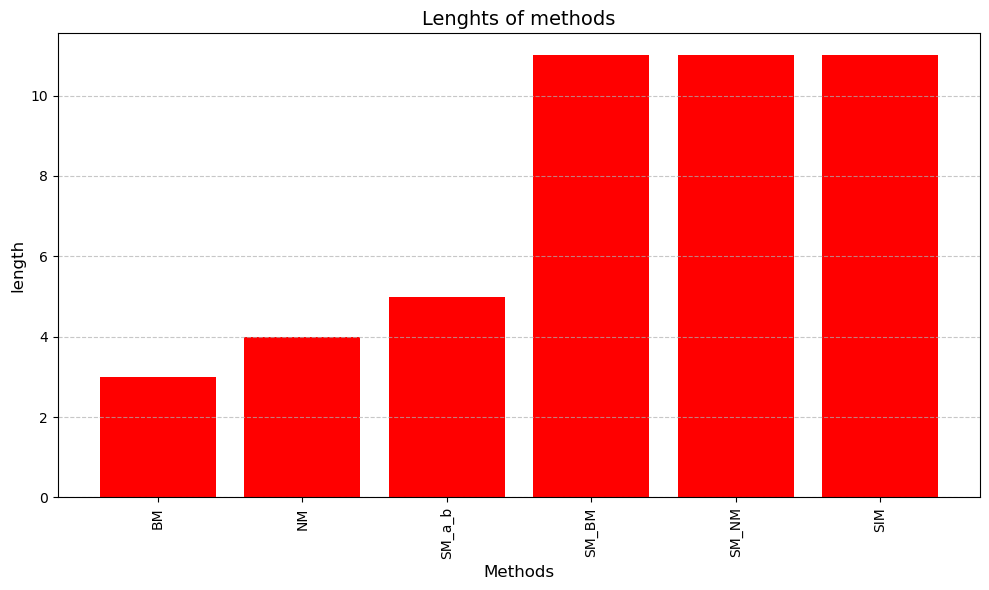

Aitken Method Part.
Final answers of methods:
Aitken Method based on bisection method final answer: 0.001951860841423948235
Aitken Method based on Newton Method final answer: 0.00004858709635993592761
Aitken Method based on Secant Method answers based on a and b final answer: -0.000001918498465429500097
Aitken Method based on Secant Method answers based on bisection method final answer: -5.044410882439672589E-9
Aitken Method based on Secant Method answers based on Newton Method final answer: e
Aitken Method based on Simple Iteration final answer: 2.500202924351374069E-8
Length of methods:
Aitken Method answers based on bisection method answers: 8
Aitken Method answers based on Newton Method answers: 2
Aitken Method answers based on Secant Method answers based on a b: 8
Aitken Method answers based on Secant Method answers based on bisection method answers: 1
Aitken Method answers based on Secant Method answers based on Newton Method answers: 76
Aitken Method answers based on Simple Iter

/home/norbert/Projects/sp - 1/analysis/choice1.py:234: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="method_names", y="lengths", join=True, capsize=0.1)


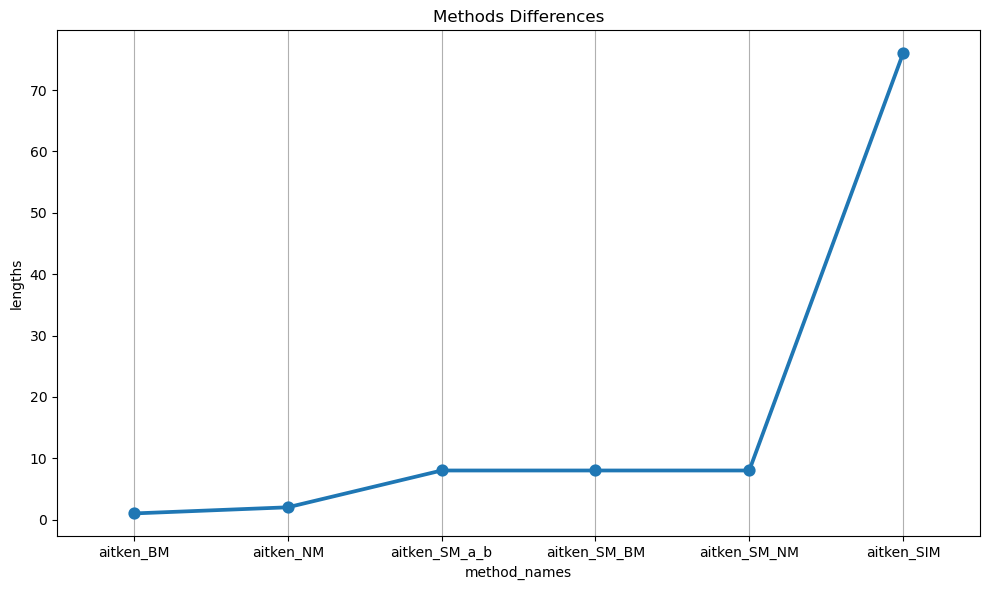

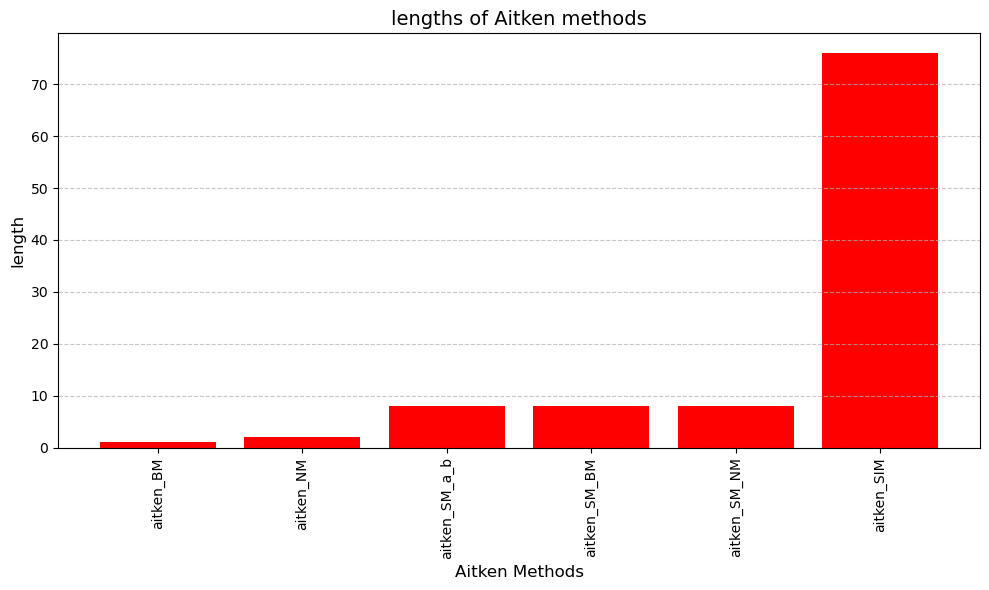

Welcome to the analyze part 2. In this part all step 2 details of the function you entered will be shown.
now here is the details of the function you entered in step 2:


Final answers of methods:
Bisection Method finall answer: 0.7548775672912597656
Newton Method finall answer: 0.7548776662466927604
Secant Method based on a and b final answer: 0.7548776121867318403
Secant Method based on bisection method finall answer: 0.7548776662466927600
Secant Method based on Newton Method final answer: 0.7548776662466927600
Simple Iteration final answer: 0.7548776875300137907


/home/norbert/Projects/sp - 1/analysis/choice2.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="Method Names", y="Finall Answers", join=True, capsize=0.1)


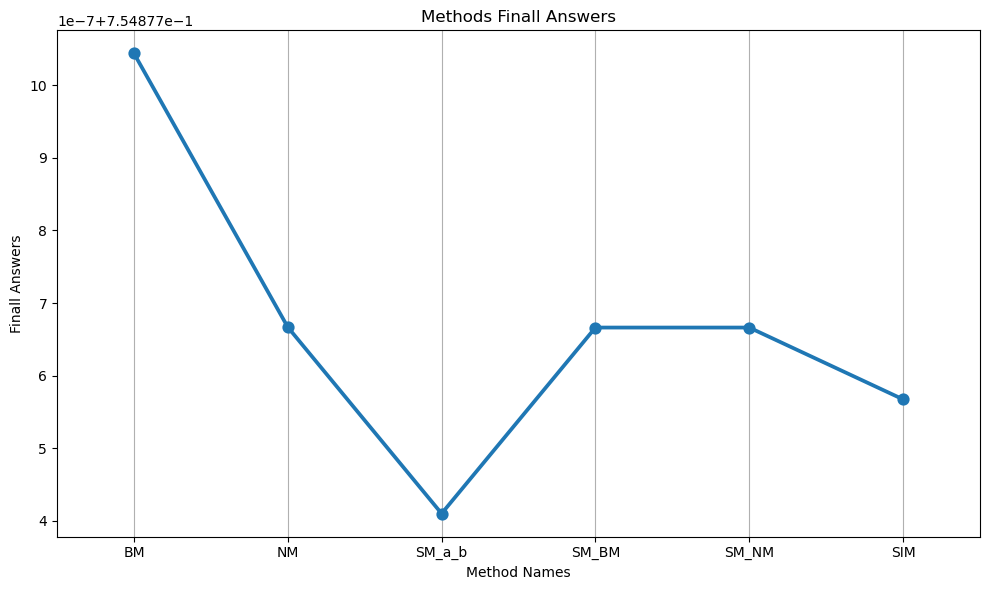

Difference between methods:
Difference between bisection method and Newton Method : 9.895543299478972571E-8
Difference between bisection method and Secant Method based on a and b : 4.489547207469377164E-8
Difference between bisection method and Secant Method based on bisection method answers : 9.895543299441025495E-8
Difference between bisection method and Secant Method based on Newton Method answers : 9.895543299442380748E-8
Difference between bisection method and Simple Iteration : 1.202387540250466616E-7
--------------------------------
Difference between Newton Method and Secant Method based on a and b : 5.405996092009595407E-8
Difference between Newton Method and Secant Method based on bisection method answers : 3.794707603699265519E-19
Difference between Newton Method and Secant Method based on Newton Method answers : 3.659182332138577465E-19
Difference between Newton Method and Simple Iteration : 2.128332103025693586E-8
--------------------------------
Difference between Secant 

/home/norbert/Projects/sp - 1/analysis/choice2.py:72: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="Method Comparison", y="Difference", join=True, capsize=0.1)


<Figure size 1000x600 with 0 Axes>

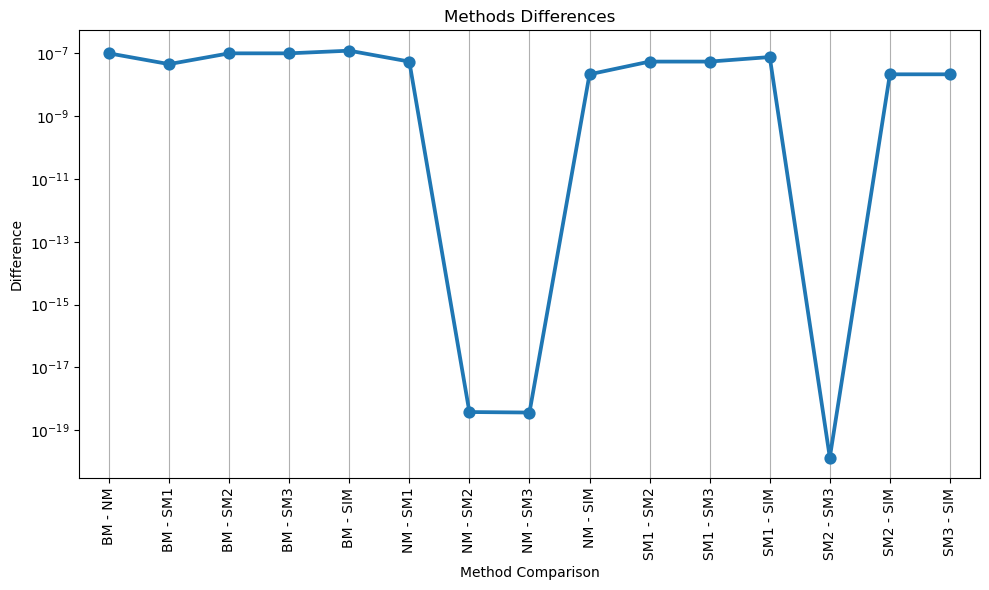

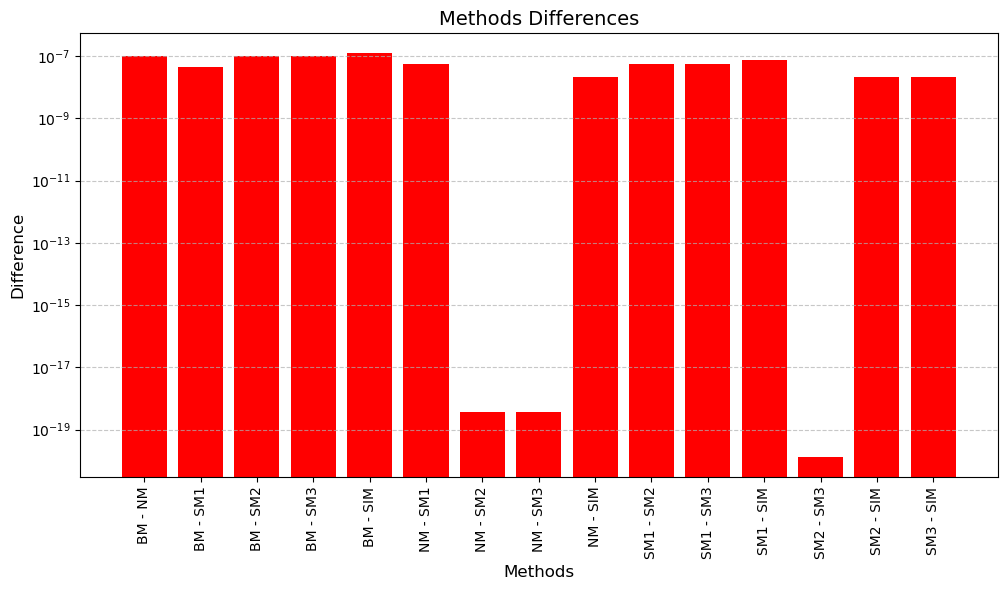

--------------------------------
Length of methods:
bisection_method_answers: 20
Newton Method answers: 4
Secant Method answers based on a and b: 10
Secant Method answers based on bisection method answers: 2
Secant Method answers based on Newton Method answers: 2
Simple Iteration answers: 2
Fastest Method: ('secant_method_answers_based_on_bisection_method_answers', 2)


/home/norbert/Projects/sp - 1/analysis/choice2.py:161: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="method_names", y="lengths", join=True, capsize=0.1)


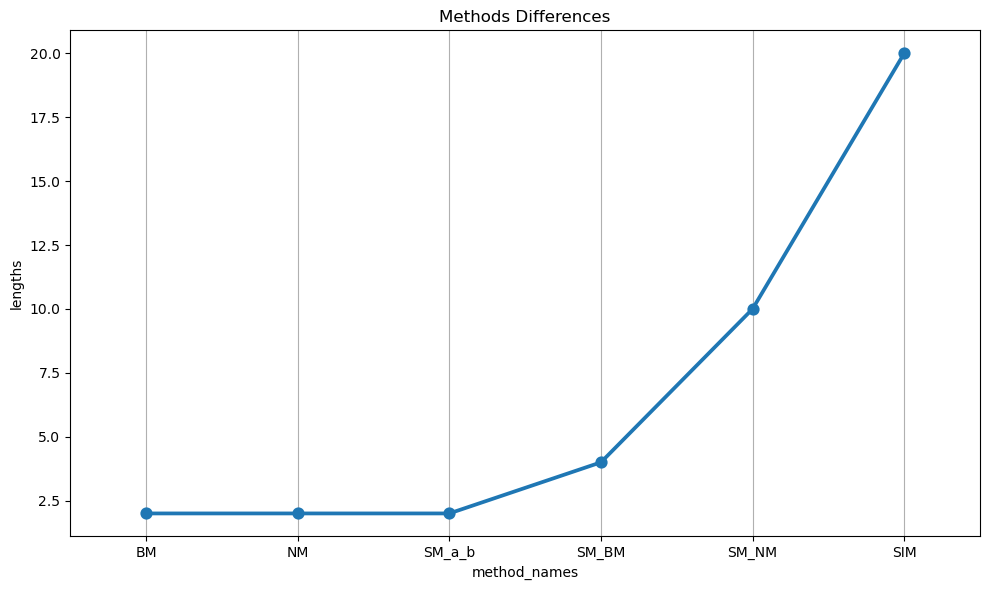

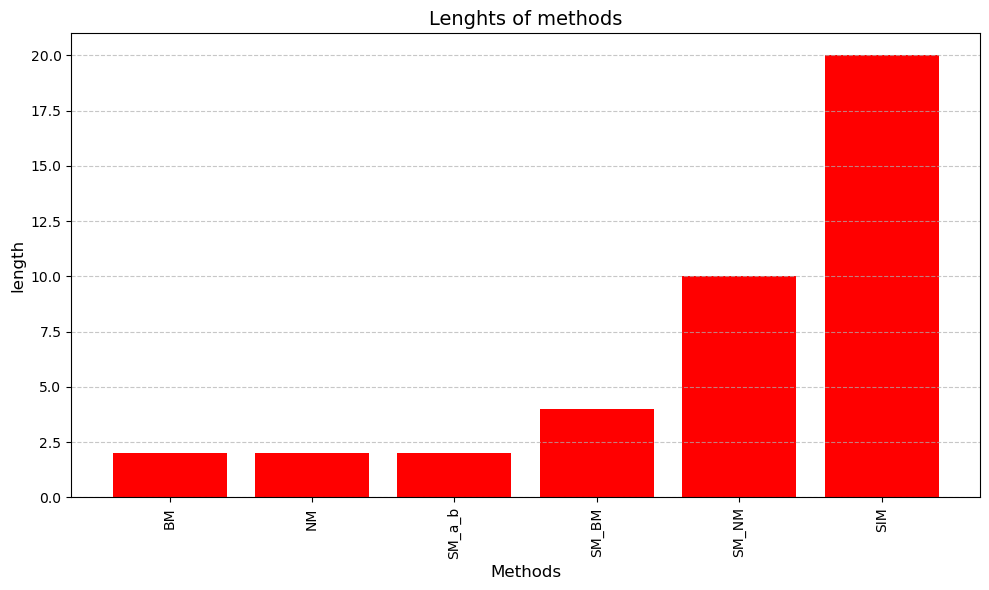

Aitken Method Part.
Final answers of methods:
Aitken Method based on bisection method final answer: -0.000001907349837636609403
Aitken Method based on Newton Method final answer: 0.00004858709635993592761
Aitken Method based on Secant Method answers based on a and b final answer: -0.000001918498465429500097
Aitken Method based on Secant Method answers based on bisection method final answer: e
Aitken Method based on Secant Method answers based on Newton Method final answer: e
Aitken Method based on Simple Iteration final answer: e
Length of methods:
Aitken Method answers based on bisection method answers: 18
Aitken Method answers based on Newton Method answers: 2
Aitken Method answers based on Secant Method answers based on a b: 8
Aitken Method answers based on Secant Method answers based on bisection method answers: 76
Aitken Method answers based on Secant Method answers based on Newton Method answers: 76
Aitken Method answers based on Simple Iteration answers: 76
Fastest Aitken Method

/home/norbert/Projects/sp - 1/analysis/choice2.py:233: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(data=df, x="method_names", y="lengths", join=True, capsize=0.1)


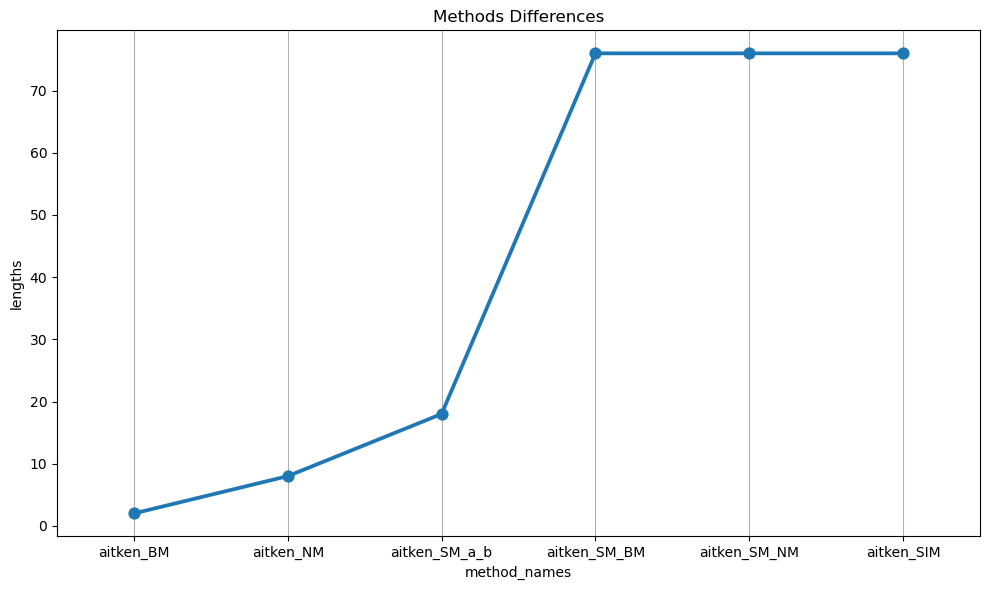

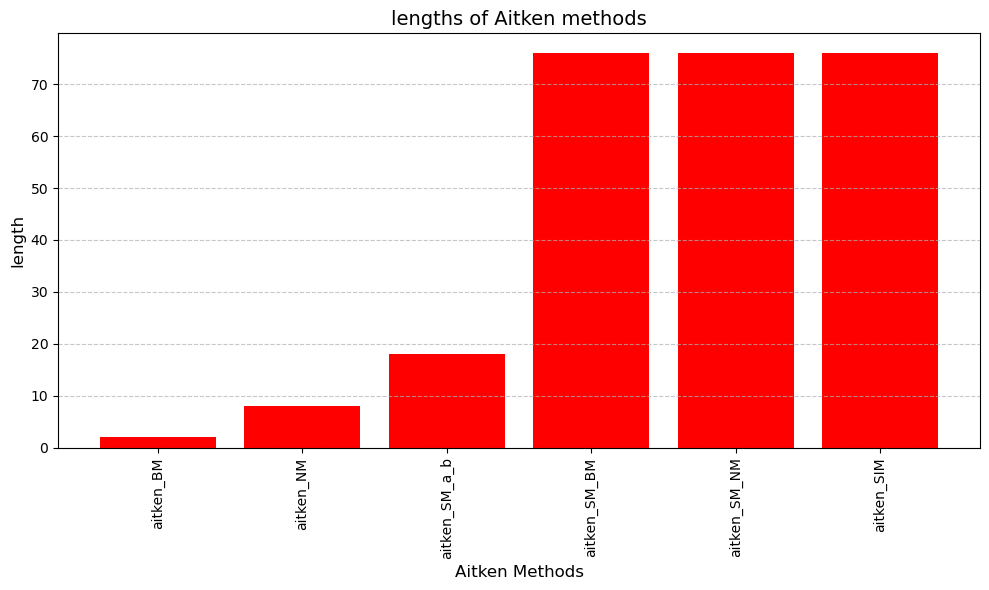

Thanks for your time!


In [49]:
if user_choice == "y":
    print("Welcome to the analyze part. In this part you can analyze the function you entered.")
    print("first here is the geneal details of the function you entered:")
    print(f"Function: {user_input}")
    print(f"Symbol: {x}")
    print(f"Interval: [{a}, {b}]")
    print("\n")

    have_root = input("Before countinue, do you know the root of the function you entered (We can use it to analyze the error of methods) (y/n) ? ")

    if have_root == "y":
        root_check = False
        while root_check == False:
            try:
                root = int(input("Enter the root: "))
                print("Thanks! You can continue.")
                root_check = True
            except:
                print("Invalid input. Please enter again")
    else:
        root = False
        print("No problem, Please countinue.")
        
    
    user_part_choice = input("Which part do you want to analyze (1/2)? ")

    if user_part_choice == "1":
        user_choice_one(bisection_method_answers, newton_method_answers, secant_method_answers_based_on_a_b, secant_method_answers_based_on_bisection_method_answers, secant_method_answers_based_on_newton_method_answers, simpleـiteration_answers, aitkenـmethod_answers_based_on_bisection_method_answers, aitkenـmethod_answers_based_on_newton_method_answers, aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b, aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers, aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers, aitkenـmethod_answers_based_on_simpleـiteration_answers, root)
        user_part_choice_again = input("This is end of Analyze Part1. Do you want to continue to analyze part2 (y/n) ? ")
        if user_part_choice_again == "y":
            user_choice_two(bisection_method_answers_step2, newton_method_answers_step2, secant_method_answers_based_on_a_b_step2, secant_method_answers_based_on_bisection_method_answers_step2, secant_method_answers_based_on_newton_method_answers_step2, simpleـiteration_answers_step2, aitkenـmethod_answers_based_on_bisection_method_answers_step2, aitkenـmethod_answers_based_on_newton_method_answers_step2, aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b_step2, aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers_step2, aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers_step2, aitkenـmethod_answers_based_on_simpleـiteration_answers_step2, root)
            print("Thanks for your time!")
        else:
            print("Thanks for your time!")


    elif user_part_choice == "2":
        user_choice_two(bisection_method_answers_step2, newton_method_answers_step2, secant_method_answers_based_on_a_b_step2, secant_method_answers_based_on_bisection_method_answers_step2, secant_method_answers_based_on_newton_method_answers_step2, simpleـiteration_answers_step2, aitkenـmethod_answers_based_on_bisection_method_answers_step2, aitkenـmethod_answers_based_on_newton_method_answers_step2, aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b_step2, aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers_step2, aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers_step2, aitkenـmethod_answers_based_on_simpleـiteration_answers_step2, root)
        user_part_choice_again = input("This is end of Analyze Part2. Do you want to check analyze part1 too (y/n)? ")
        if user_part_choice_again == "y":
            user_choice_one(bisection_method_answers, newton_method_answers, secant_method_answers_based_on_a_b, secant_method_answers_based_on_bisection_method_answers, secant_method_answers_based_on_newton_method_answers, simpleـiteration_answers, aitkenـmethod_answers_based_on_bisection_method_answers, aitkenـmethod_answers_based_on_newton_method_answers, aitkenـmethod_answers_based_on_secant_method_answers_based_on_a_b, aitkenـmethod_answers_based_on_secant_method_answers_based_on_bisection_method_answers, aitkenـmethod_answers_based_on_secant_method_answers_based_on_newton_method_answers, aitkenـmethod_answers_based_on_simpleـiteration_answers, root)
            print("Thanks for your time!")
        else:
            print("Thanks for your time!")
else:
    print("Thanks for your time!")